## Importing Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import os
import glob

## Load Dataset & EDA

In [8]:
# Root directory
ROOT = "./datasets/1_NCA"

csv_files = glob.glob(os.path.join(ROOT, "*.csv"))
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

print(f"Total files read: {len(dataframes)}")

Total files read: 66


In [10]:
df1 = pd.read_csv("datasets/1_NCA/CY25-1_1-#1.csv")
df1.head(10)

,time/s,control/V/mA,Ecell/V,<I>/mA,Q discharge/mA.h,Q charge/mA.h,control/V,control/mA,cycle number
0,0.000,3500.0,3.149101,0.058311,0.0,0.001944,0.0,3500,2
1,0.014,3500.0,3.154381,3499.796569,0.0,0.015554,0.0,3500,2
2,0.070,3500.0,3.159463,3500.127389,0.0,0.070001,0.0,3500,2
3,0.202,3500.0,3.164467,3500.217622,0.0,0.198342,0.0,3500,2
4,0.412,3500.0,3.169628,3500.402831,0.0,0.402532,0.0,3500,2
5,0.682,3500.0,3.174632,3500.313356,0.0,0.665056,0.0,3500,2
6,0.988,3500.0,3.179675,3500.408428,0.0,0.962590,0.0,3500,2
7,1.342,3500.0,3.184758,3500.325451,0.0,1.306789,0.0,3500,2
8,1.732,3500.0,3.189801,3500.398931,0.0,1.685999,0.0,3500,2
9,2.148,3500.0,3.194844,3500.469302,0.0,2.090498,0.0,3500,2


We can directly estimate the SoC from this dataset, but estimating the SoH is not feasilble, beacuse there is full-cycle or long term degradation information in this dataset.

`SoC Estimation Methods:`
1. Coulomb Counting.
2. Using Charge and Discharge.
3. Voltage-based (but need to use OCV-SoC curve, or Physics law).

`SoH Estimation Methods:`
1. Need to do capacity fade modeling.
2. Resistance growth.
3. Learned degradation patterns.

In [20]:
print("Shape:", df1.shape)

Shape: (32900, 9)


In [19]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32900 entries, 0 to 32899
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time/s            32900 non-null  float64
 1   control/V/mA      32900 non-null  float64
 2   Ecell/V           32900 non-null  float64
 3   <I>/mA            32900 non-null  float64
 4   Q discharge/mA.h  32900 non-null  float64
 5   Q charge/mA.h     32900 non-null  float64
 6   control/V         32900 non-null  float64
 7   control/mA        32900 non-null  int64  
 8   cycle number      32900 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 2.3 MB


In [18]:
df1.isnull().sum()

time/s              0
control/V/mA        0
Ecell/V             0
<I>/mA              0
Q discharge/mA.h    0
Q charge/mA.h       0
control/V           0
control/mA          0
cycle number        0
dtype: int64

In [21]:
df1.describe()

,time/s,control/V/mA,Ecell/V,<I>/mA,Q discharge/mA.h,Q charge/mA.h,control/V,control/mA,cycle number
count,32900.000000,32900.000000,32900.000000,32900.000000,32900.000000,32900.000000,32900.000000,32900.000000,32900.000000
mean,233474.499171,-340.103199,3.841720,6.982003,511.589479,1478.198445,2.024460,-342.127660,19.298176
std,135028.693933,2416.707116,0.459497,2532.326488,963.971199,1296.472793,2.098708,2416.419581,10.088837
min,0.000000,-3500.000000,2.649827,-3499.610674,0.000000,0.000000,0.000000,-3500.000000,2.000000
25%,116820.428600,-3500.000000,3.523517,-3498.486865,0.000000,0.000000,0.000000,-3500.000000,11.000000
50%,233489.360800,4.200072,4.162050,345.021131,0.000000,1943.383681,0.000000,0.000000,19.000000
75%,352162.470100,4.200072,4.200169,1464.632431,443.490336,2745.375998,4.200072,0.000000,28.000000
max,464986.723900,3500.000000,4.200445,3501.888424,3149.265766,3169.993505,4.200072,3500.000000,36.000000


In [28]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("\nConstant columns:", constant_cols)

variable_cols = [col for col in df.columns if df[col].nunique() > 1]
print("Variable columns:", variable_cols)

cycles = df["cycle number"].unique()
print(f"\nTotal cycles: {len(cycles)}, Range: {cycles.min()} - {cycles.max()}")


Constant columns: []
Variable columns: ['time/s', 'control/V/mA', 'Ecell/V', '<I>/mA', 'Q discharge/mA.h', 'Q charge/mA.h', 'control/V', 'control/mA', 'cycle number']

Total cycles: 415, Range: 1.0 - 415.0



Cycle summary (first 10):
    cycle number   duration_s  max_voltage  min_voltage  mean_current  \
0             2  12511.96059     4.200366     2.649945     39.502207   
1             3  12313.34860     4.200366     2.649985     37.615848   
2             4  12912.35665     4.200366     2.649945     47.515119   
3             5  12720.71863     4.200287     2.649945     44.480273   
4             6  13035.93666     4.200326     2.649945     47.706782   
5             7  12842.57065     4.200287     2.649906     39.449441   
6             8  13091.61898     4.200326     2.649867     38.862166   
7             9  13093.09740     4.200287     2.649906     41.997208   
8            10  13090.29530     4.200287     2.649985     37.522253   
9            11  13091.09130     4.200326     2.649867     32.646524   

   max_Q_discharge  max_Q_charge  
0      3141.952750   3167.135066  
1      3144.995988   3166.161775  
2      3149.265766   3169.993505  
3      3148.204865   3168.332858  
4   

Text(0.5, 0.98, 'Battery EDA - Time Series per Cycle')

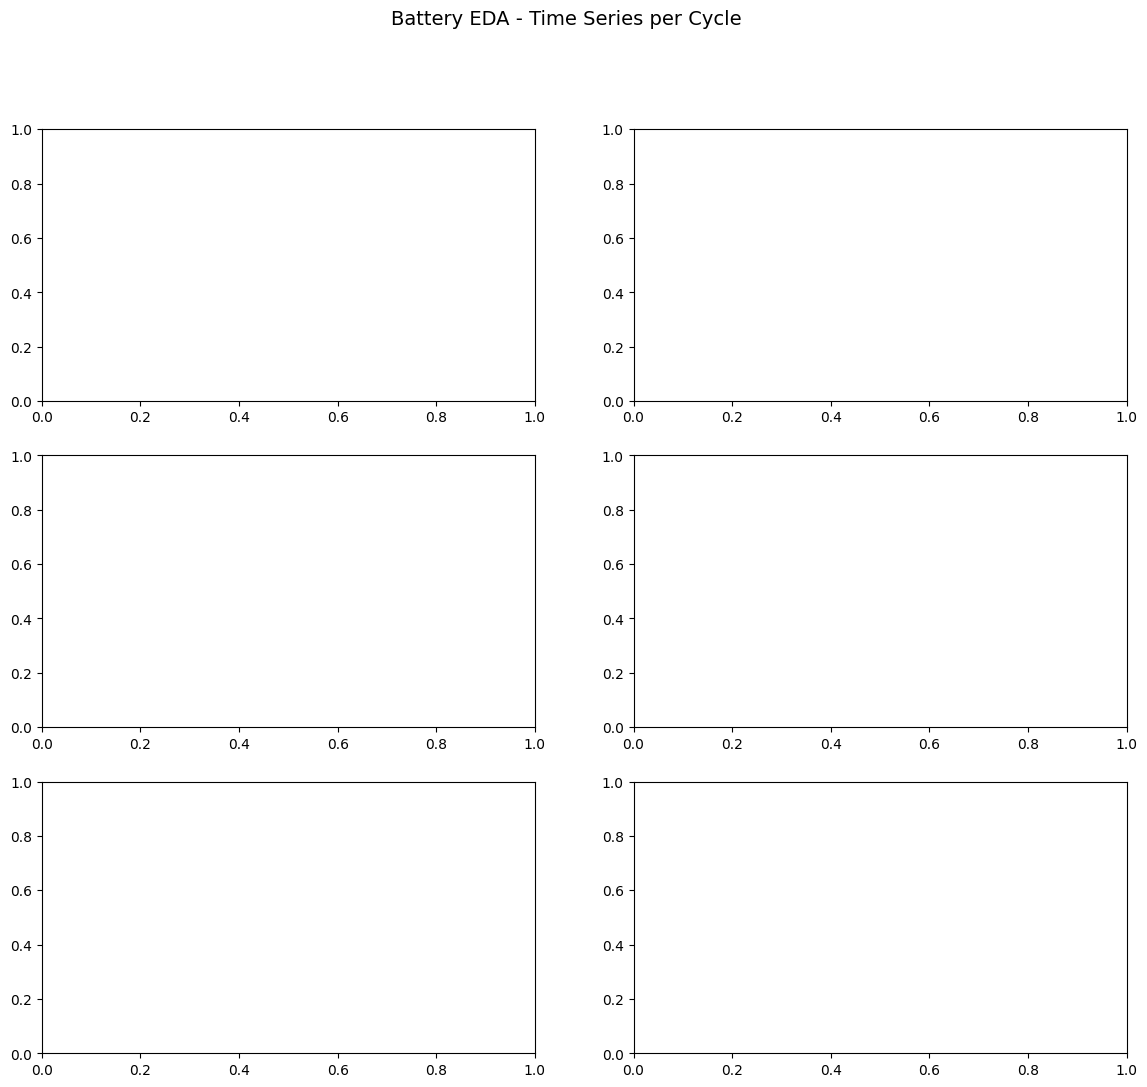

In [30]:
cycle_summary = df1.groupby("cycle number").agg(
    duration_s=("time/s", lambda x: x.max() - x.min()),
    max_voltage=("Ecell/V", "max"),
    min_voltage=("Ecell/V", "min"),
    mean_current=("<I>/mA", "mean"),
    max_Q_discharge=("Q discharge/mA.h", "max"),
    max_Q_charge=("Q charge/mA.h", "max"),
).reset_index()
print("\nCycle summary (first 10):\n", cycle_summary.head(10))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Battery EDA - Time Series per Cycle", fontsize=14)

<Figure size 640x480 with 0 Axes>

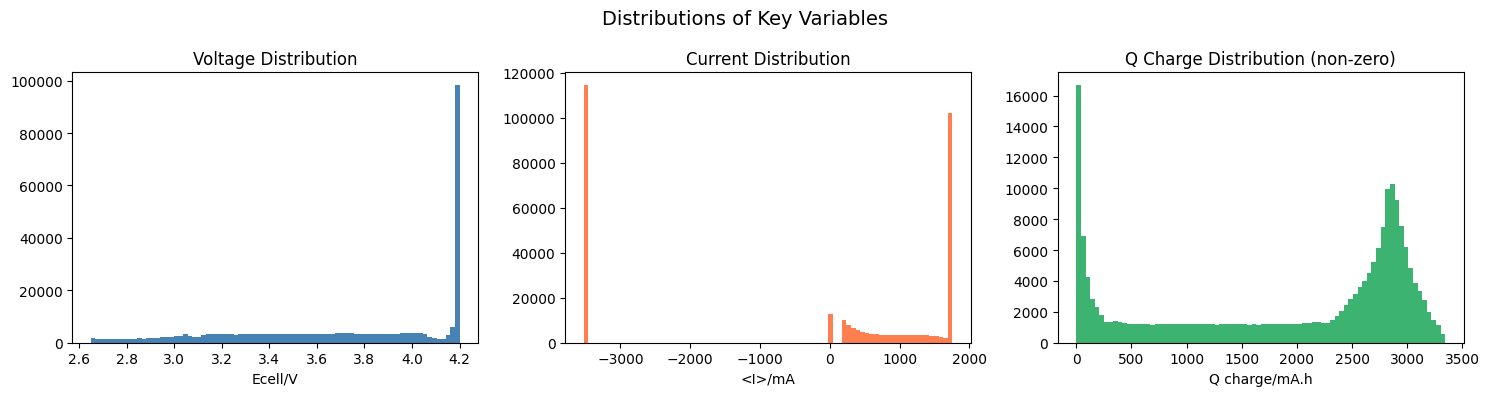

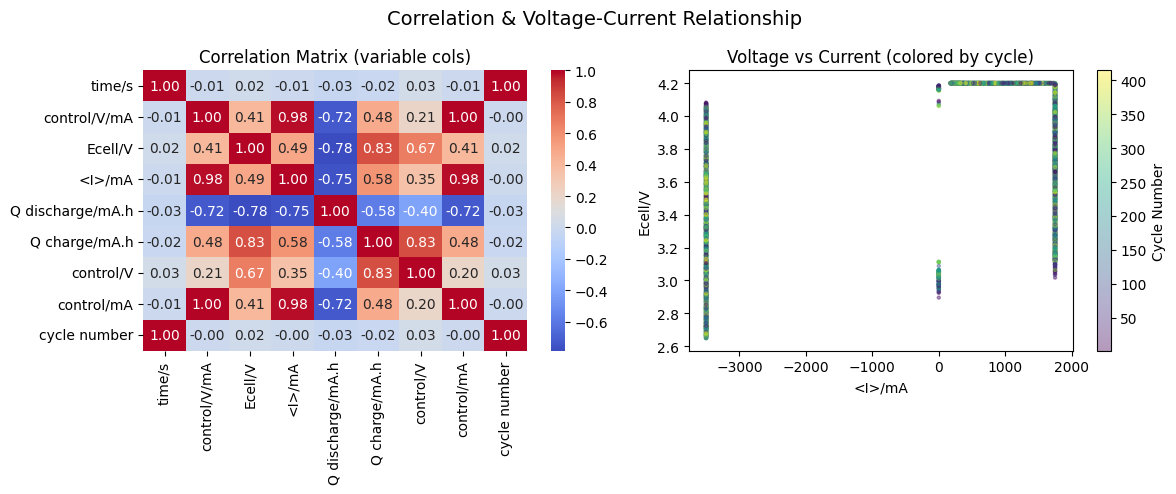


SoH proxy (first 10 cycles):
    cycle number  max_Q_charge  SoH_proxy
0             2   3167.135066  94.675397
1             3   3166.161775  94.646303
2             4   3169.993505  94.760845
3             5   3168.332858  94.711203
4             6   3163.709340  94.572992
5             7   3157.262669  94.380281
6             8   3151.621111  94.211637
7             9   3143.084993  93.956467
8            10   3132.028947  93.625967
9            11   3120.832821  93.291281

SoC proxy sample:
    time/s  cycle number  Q charge/mA.h     SoC_proxy
0   0.000           1.0       0.000971  2.902516e-07
1   0.204           1.0       0.100071  2.991437e-05
2   0.706           1.0       0.343971  1.028236e-04
3   1.360           1.0       0.661706  1.978041e-04
4   2.186           1.0       1.063009  3.177660e-04
5   3.110           1.0       1.511934  4.519636e-04
6   4.202           1.0       2.042481  6.105603e-04
7   5.348           1.0       2.599258  7.769980e-04
8   6.604           1

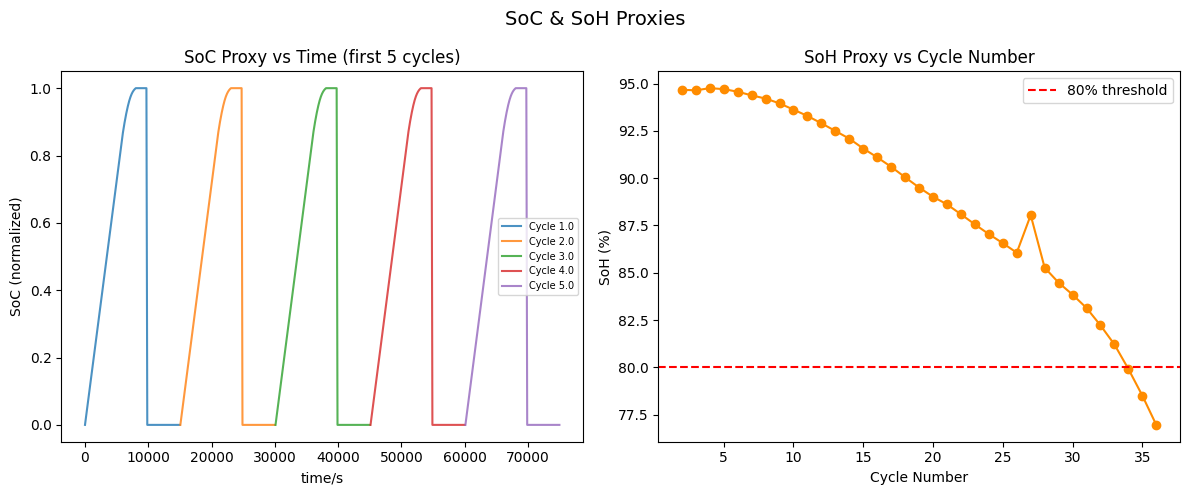

In [33]:
for cycle in cycles[:5]:
    mask = df["cycle number"] == cycle
    sub = df[mask]
    axes[0, 0].plot(sub["time/s"], sub["Ecell/V"], label=f"Cycle {cycle}", alpha=0.7)
axes[0, 0].set_title("Voltage (Ecell/V) vs Time")
axes[0, 0].set_xlabel("time/s")
axes[0, 0].set_ylabel("Ecell/V")
axes[0, 0].legend(fontsize=7)

for cycle in cycles[:5]:
    mask = df["cycle number"] == cycle
    sub = df[mask]
    axes[0, 1].plot(sub["time/s"], sub["<I>/mA"], label=f"Cycle {cycle}", alpha=0.7)
axes[0, 1].set_title("Current (<I>/mA) vs Time")
axes[0, 1].set_xlabel("time/s")
axes[0, 1].set_ylabel("<I>/mA")
axes[0, 1].legend(fontsize=7)

for cycle in cycles[:5]:
    mask = df["cycle number"] == cycle
    sub = df[mask]
    axes[1, 0].plot(sub["time/s"], sub["Q discharge/mA.h"], label=f"Cycle {cycle}", alpha=0.7)
axes[1, 0].set_title("Q Discharge vs Time")
axes[1, 0].set_xlabel("time/s")
axes[1, 0].set_ylabel("Q discharge/mA.h")
axes[1, 0].legend(fontsize=7)

for cycle in cycles[:5]:
    mask = df["cycle number"] == cycle
    sub = df[mask]
    axes[1, 1].plot(sub["time/s"], sub["Q charge/mA.h"], label=f"Cycle {cycle}", alpha=0.7)
axes[1, 1].set_title("Q Charge vs Time")
axes[1, 1].set_xlabel("time/s")
axes[1, 1].set_ylabel("Q charge/mA.h")
axes[1, 1].legend(fontsize=7)

axes[2, 0].plot(cycle_summary["cycle number"], cycle_summary["max_Q_discharge"], marker="o", label="Max Q Discharge")
axes[2, 0].plot(cycle_summary["cycle number"], cycle_summary["max_Q_charge"], marker="s", label="Max Q Charge")
axes[2, 0].set_title("Capacity vs Cycle Number (SoH proxy)")
axes[2, 0].set_xlabel("Cycle Number")
axes[2, 0].set_ylabel("Capacity (mA.h)")
axes[2, 0].legend()

axes[2, 1].plot(cycle_summary["cycle number"], cycle_summary["max_voltage"], label="Max Voltage")
axes[2, 1].plot(cycle_summary["cycle number"], cycle_summary["min_voltage"], label="Min Voltage")
axes[2, 1].set_title("Voltage Range per Cycle")
axes[2, 1].set_xlabel("Cycle Number")
axes[2, 1].set_ylabel("Ecell/V")
axes[2, 1].legend()

plt.tight_layout()
plt.savefig("eda_timeseries.png", dpi=150)
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Distributions of Key Variables", fontsize=14)

axes2[0].hist(df["Ecell/V"], bins=80, color="steelblue", edgecolor="none")
axes2[0].set_title("Voltage Distribution")
axes2[0].set_xlabel("Ecell/V")

axes2[1].hist(df["<I>/mA"], bins=80, color="coral", edgecolor="none")
axes2[1].set_title("Current Distribution")
axes2[1].set_xlabel("<I>/mA")

axes2[2].hist(df["Q charge/mA.h"].replace(0, np.nan).dropna(), bins=80, color="mediumseagreen", edgecolor="none")
axes2[2].set_title("Q Charge Distribution (non-zero)")
axes2[2].set_xlabel("Q charge/mA.h")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle("Correlation & Voltage-Current Relationship", fontsize=14)

corr_df = df[variable_cols].corr()
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", ax=axes3[0])
axes3[0].set_title("Correlation Matrix (variable cols)")

sample = df.sample(min(5000, len(df)), random_state=42)
sc = axes3[1].scatter(sample["<I>/mA"], sample["Ecell/V"], c=sample["cycle number"], cmap="viridis", alpha=0.4, s=5)
plt.colorbar(sc, ax=axes3[1], label="Cycle Number")
axes3[1].set_title("Voltage vs Current (colored by cycle)")
axes3[1].set_xlabel("<I>/mA")
axes3[1].set_ylabel("Ecell/V")

plt.tight_layout()
plt.savefig("eda_corr.png", dpi=150)
plt.show()

first_cycle = df[df["cycle number"] == cycles[0]]["Q charge/mA.h"].max()
cycle_summary["SoH_proxy"] = cycle_summary["max_Q_charge"] / first_cycle * 100
print("\nSoH proxy (first 10 cycles):\n", cycle_summary[["cycle number", "max_Q_charge", "SoH_proxy"]].head(10))

df_sorted = df.sort_values(["cycle number", "time/s"])
df_sorted["SoC_proxy"] = df_sorted.groupby("cycle number")["Q charge/mA.h"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
)
print("\nSoC proxy sample:\n", df_sorted[["time/s", "cycle number", "Q charge/mA.h", "SoC_proxy"]].head(10))

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle("SoC & SoH Proxies", fontsize=14)

for cycle in cycles[:5]:
    mask = df_sorted["cycle number"] == cycle
    sub = df_sorted[mask]
    axes4[0].plot(sub["time/s"], sub["SoC_proxy"], label=f"Cycle {cycle}", alpha=0.8)
axes4[0].set_title("SoC Proxy vs Time (first 5 cycles)")
axes4[0].set_xlabel("time/s")
axes4[0].set_ylabel("SoC (normalized)")
axes4[0].legend(fontsize=7)

axes4[1].plot(cycle_summary["cycle number"], cycle_summary["SoH_proxy"], marker="o", color="darkorange")
axes4[1].set_title("SoH Proxy vs Cycle Number")
axes4[1].set_xlabel("Cycle Number")
axes4[1].set_ylabel("SoH (%)")
axes4[1].axhline(80, color="red", linestyle="--", label="80% threshold")
axes4[1].legend()

plt.tight_layout()
plt.savefig("eda_soc_soh.png", dpi=150)
plt.show()